In [7]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

token_file = Path("captures/20260415T211540Z_groq_qwen3_32b_summarisation_9306496a.tokens.json")


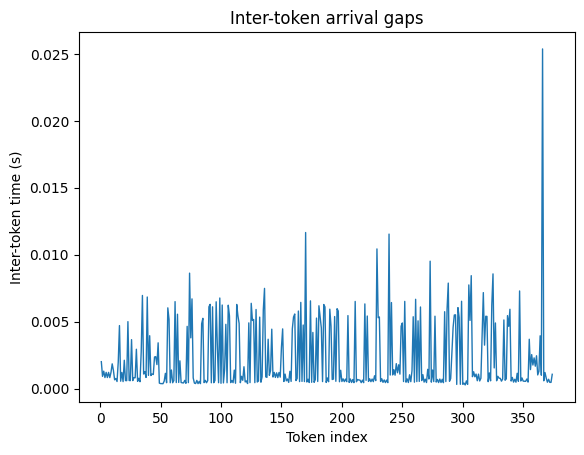

In [26]:
#Single prompt:
with open(token_file) as f:
    tokens = json.load(f)

t = np.array([x["t_rel"] for x in tokens])

# compute inter-token time differences
dt = np.diff(t)

# x-axis aligns with "token index of the gap"
x = np.arange(1, len(t))

plt.plot(x, dt, linewidth=1)
plt.xlabel("Token index")
plt.ylabel("Inter-token time (s)")
plt.title("Inter-token arrival gaps")
plt.show()

C:\Users\AS9Wa\AppData\Local\Temp\ipykernel_24124\1278577970.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=6, ncol=2)


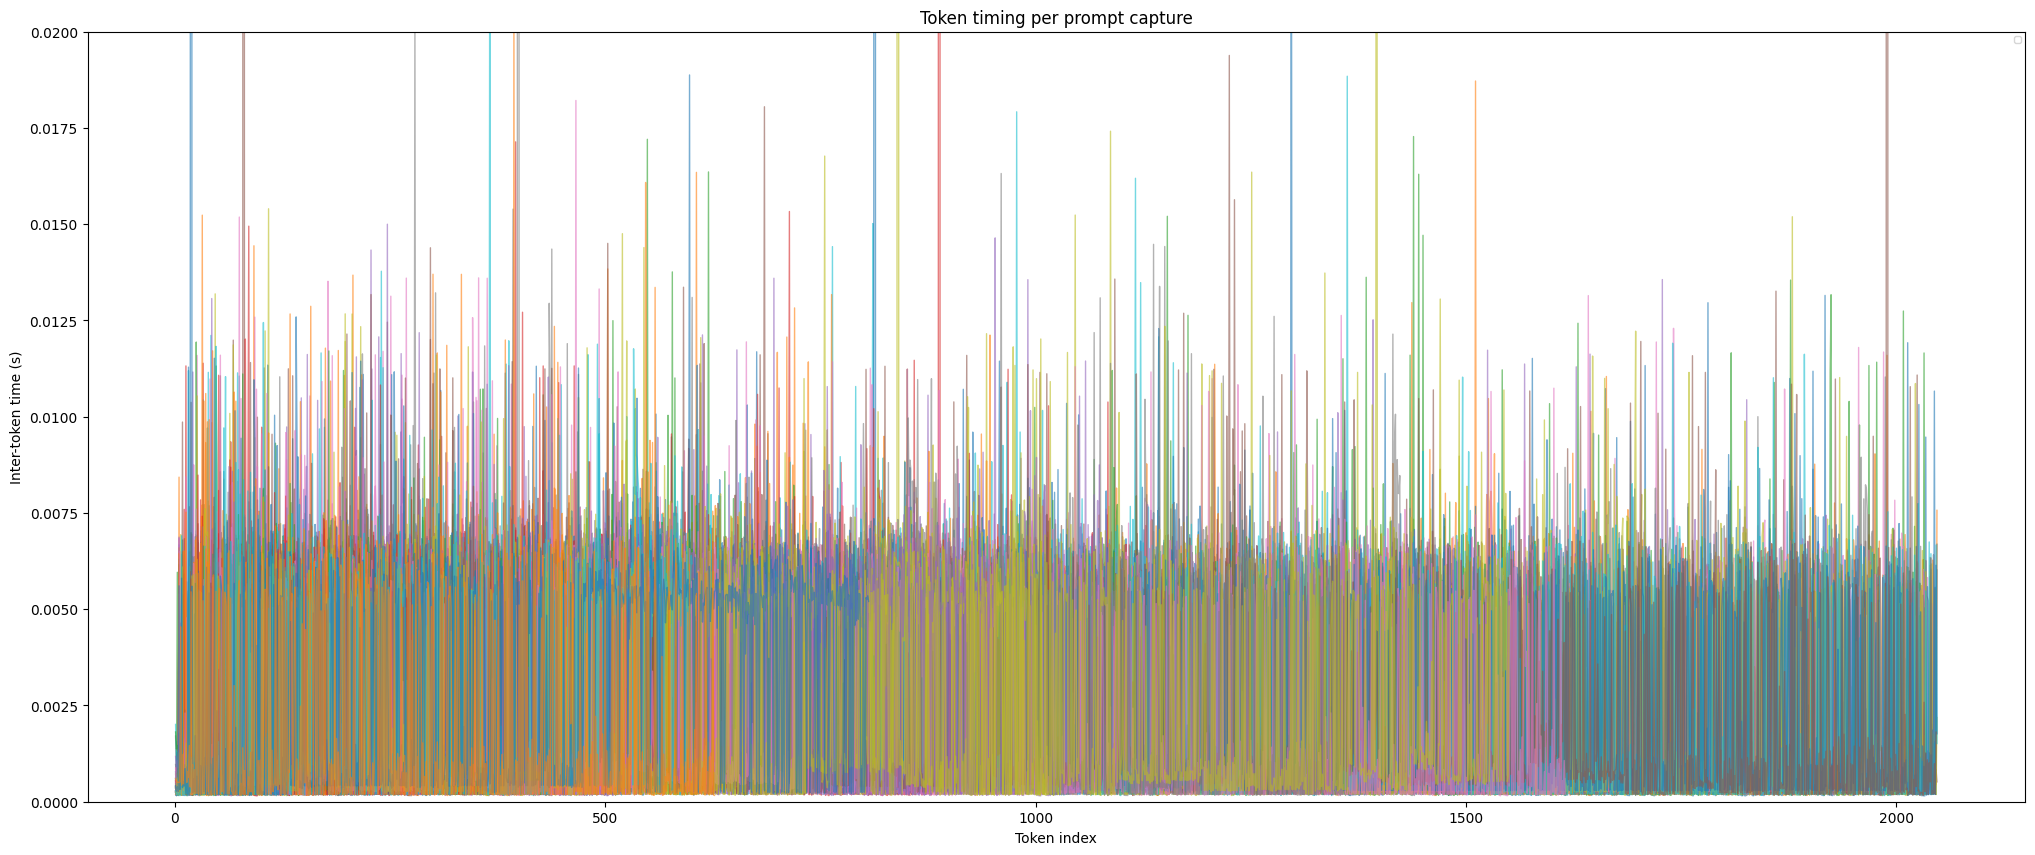

In [ ]:
#All prompts:
token_files = list(Path("captures").glob("*.tokens.json"))

plt.figure(figsize=(25, 10))

for file in token_files:
    with open(file) as f:
        tokens = json.load(f)

    if len(tokens) < 2:
        continue

    t = np.array([x["t_rel"] for x in tokens])

    # inter-token times
    dt = np.diff(t)

    x = np.arange(1, len(t))

    label = file.stem.replace(".tokens", "")

    plt.plot(x, dt, alpha=0.6, linewidth=1)#, label=label)
    
plt.xlabel("Token index")
plt.ylabel("Inter-token time (s)")
plt.title("Token timing per prompt capture")
plt.legend(fontsize=6, ncol=2)
plt.ylim(0, 0.02)

plt.show()

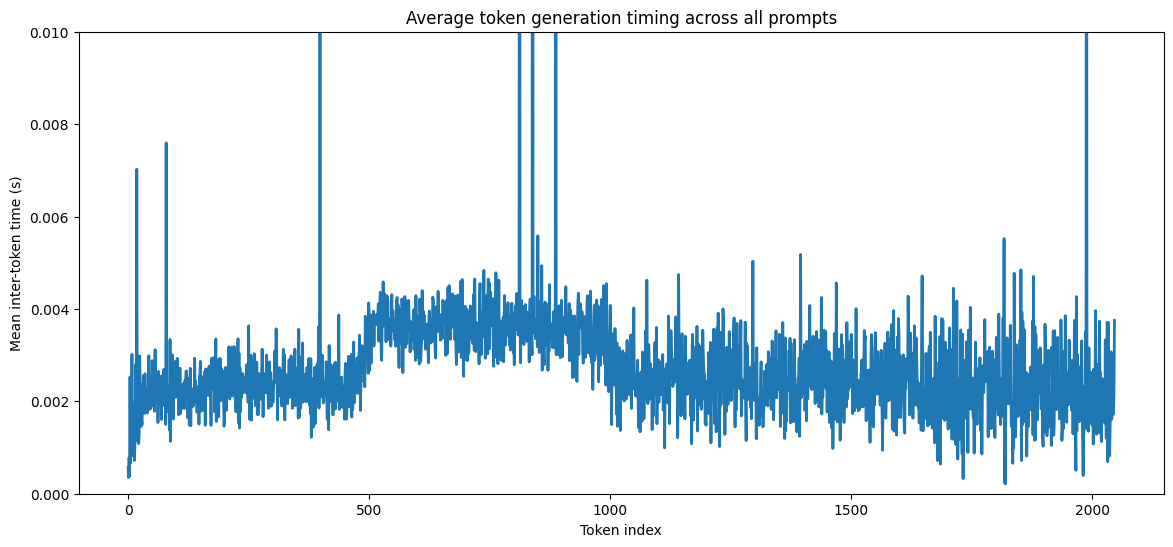

In [28]:
#Average of all prompts:
all_dts = []

max_len = 0

# first pass: compute all dt arrays
for file in token_files:
    with open(file) as f:
        tokens = json.load(f)

    if len(tokens) < 2:
        continue

    t = np.array([x["t_rel"] for x in tokens])
    dt = np.diff(t)

    all_dts.append(dt)
    max_len = max(max_len, len(dt))

# second pass: pad to same length
aligned = []

for dt in all_dts:
    padded = np.pad(dt, (0, max_len - len(dt)), constant_values=np.nan)
    aligned.append(padded)

aligned = np.array(aligned)

# mean across files (ignore NaNs)
mean_dt = np.nanmean(aligned, axis=0)

# plot
plt.figure(figsize=(14, 6))
plt.plot(mean_dt, linewidth=2)

plt.xlabel("Token index")
plt.ylabel("Mean inter-token time (s)")
plt.title("Average token generation timing across all prompts")
plt.ylim(0, 0.01)
#plt.xlim(0, 250)
plt.show()